<a href="https://colab.research.google.com/github/Likhithaa-Guntaka/ai-skills-market-intelligence/blob/main/notebooks/04_final_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Title:** Tracking the AI Skills Revolution: How Demand for AI & Data Skills Is Changing (2022–Present)

by Likhitha Guntaka


## **Project objective:** To analyze the global demand for AI and Data-related skills by integrating two real-time data sources: the Adzuna Jobs API and the StackOverflow Developer Activity API.

## Data overview:(Include data source, year, number of observations)

## D1. Library imports

In [ ]:
# Used to send requests to online APIs
import requests

# Used to store and manipulate data in tables (DataFrames)
import pandas as pd

# Used for numerical operations (like handling missing values)
import numpy as np

# Used to work with dates and timestamps
from datetime import datetime

##D2. Data pre-processing

### AP1-1: Adzuna (Jobs API)
**Connecting to Adzuna Jobs API**
* This API provides real job postings related to AI, Data, and Technology.
* By default, the data is collected **globally**.
* I also added a city filter that can be switched ON to analyze specific locations such as New York, London, or San Francisco in Phase III.


In [ ]:
# CITY FILTER SWITCH
# By default, this is set to GLOBAL (False)
# Change to True if you want to analyze a specific city
use_city_filter = False

# You can change this to: "New York", "London", "San Francisco", etc.
city_name = "New York"

# False = Global data
# True = City-specific data
# Only need to change ONE word to switch

In [ ]:
# Connect to Adzuna API

# Credentials are loaded from Colab Secrets (sidebar -> Secrets / key icon).
# Add ADZUNA_APP_ID and ADZUNA_APP_KEY there and enable notebook access.
# Outside Colab, set them as environment variables of the same name.
import os

try:
    from google.colab import userdata
    APP_ID = userdata.get("ADZUNA_APP_ID")
    APP_KEY = userdata.get("ADZUNA_APP_KEY")
except ImportError:
    APP_ID = os.environ["ADZUNA_APP_ID"]
    APP_KEY = os.environ["ADZUNA_APP_KEY"]

# Using US Adzuna endpoint for job market analysis
adzuna_url = "https://api.adzuna.com/v1/api/jobs/us/search/1"

# Parameters for the request
params = {
    "app_id": APP_ID,
    "app_key": APP_KEY,
    "results_per_page": 100,
    "what": "AI OR Data OR Machine Learning"
}

# If the city filter is ON, add location to the query
if use_city_filter:
    params["where"] = city_name

# Header to avoid being blocked
headers = {
    "User-Agent": "Mozilla/5.0"
}

# Send request to Adzuna
response = requests.get(adzuna_url, params=params, headers=headers)

# Confirm request success
# Redact credentials before printing so they never land in saved notebook output
safe_url = response.url.replace(APP_ID, "<APP_ID>").replace(APP_KEY, "<APP_KEY>")
print("Final URL:", safe_url)
print("Status Code:", response.status_code)
print("Using city filter:", use_city_filter)
print("City:", city_name if use_city_filter else "GLOBAL")

Final URL: https://api.adzuna.com/v1/api/jobs/us/search/1?app_id=<APP_ID>&app_key=<APP_KEY>&results_per_page=100&what=AI+OR+Data+OR+Machine+Learning
Status Code: 200
Using city filter: False
City: GLOBAL


In [ ]:
# Pagination: Pull multiple pages of results

all_jobs = []

# Loop through first 3 pages (you can increase later)
for page in range(1, 4):   # pages 1, 2, 3
    url = f"https://api.adzuna.com/v1/api/jobs/us/search/{page}"
    response = requests.get(url, params=params)

    # Convert each page to JSON
    data = response.json()

    # Add job results from this page to master list
    for job in data.get("results", []):
        all_jobs.append(job)

# Convert to DataFrame
print("Total jobs pulled:", len(all_jobs))

adzuna_df = pd.DataFrame(all_jobs)

# Show a few rows
adzuna_df.head()

Total jobs pulled: 150


,id,company,salary_is_predicted,latitude,adref,created,location,__CLASS__,category,salary_max,salary_min,description,title,redirect_url,longitude,contract_time,contract_type
0,5322362078,{'__CLASS__': 'Adzuna::API::Response::Company'...,1,34.076445,eyJhbGciOiJIUzI1NiJ9.eyJzIjoicnRSYW5PSFU4QkdwN...,2025-07-25T17:02:41Z,{'__CLASS__': 'Adzuna::API::Response::Location...,Adzuna::API::Response::Job,{'__CLASS__': 'Adzuna::API::Response::Category...,130821.55,130821.55,"At EY, we're all in to shape your future with ...","Service Delivery Center, AI & Data, Machine Le...",https://www.adzuna.com/land/ad/5322362078?se=r...,-84.300837,NaN,NaN
1,5322148408,{'__CLASS__': 'Adzuna::API::Response::Company'...,1,35.215140,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTMyMjE0ODQwOCIsI...,2025-07-25T16:47:03Z,"{'area': ['US', 'North Carolina', 'Mecklenburg...",Adzuna::API::Response::Job,"{'label': 'IT Jobs', 'tag': 'it-jobs', '__CLAS...",127621.55,127621.55,"At EY, we're all in to shape your future with ...","Service Delivery Center, AI & Data, Machine Le...",https://www.adzuna.com/land/ad/5322148408?se=r...,-80.827790,NaN,NaN
2,5387308767,"{'display_name': 'EY', '__CLASS__': 'Adzuna::A...",1,35.215140,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4NzMwODc2NyIsI...,2025-09-06T17:30:51Z,"{'display_name': 'Charlotte, Mecklenburg Count...",Adzuna::API::Response::Job,"{'tag': 'it-jobs', 'label': 'IT Jobs', '__CLAS...",115204.91,115204.91,"Location: Manayunk, Charlotte, San Antonio, Ja...","Service Delivery Center, AI & Data, Machine Le...",https://www.adzuna.com/land/ad/5387308767?se=r...,-80.827790,NaN,NaN
3,5387568957,"{'display_name': 'EY', '__CLASS__': 'Adzuna::A...",1,34.076445,eyJhbGciOiJIUzI1NiJ9.eyJzIjoicnRSYW5PSFU4QkdwN...,2025-09-06T18:11:02Z,"{'area': ['US', 'Georgia', 'Fulton County', 'A...",Adzuna::API::Response::Job,"{'label': 'IT Jobs', 'tag': 'it-jobs', '__CLAS...",118093.46,118093.46,"Location: Manayunk, Charlotte, San Antonio, Ja...","Service Delivery Center, AI & Data, Machine Le...",https://www.adzuna.com/land/ad/5387568957?se=r...,-84.300837,NaN,NaN
4,5388250665,{'__CLASS__': 'Adzuna::API::Response::Company'...,1,30.291980,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4ODI1MDY2NSIsI...,2025-09-07T09:34:51Z,{'__CLASS__': 'Adzuna::API::Response::Location...,Adzuna::API::Response::Job,{'__CLASS__': 'Adzuna::API::Response::Category...,111721.13,111721.13,"Location: Manayunk, Charlotte, San Antonio, Ja...","Service Delivery Center, AI & Data, Machine Le...",https://www.adzuna.com/details/5388250665?utm_...,-81.634930,NaN,NaN


In [ ]:
adzuna_df.shape

(150, 17)

#### Converting Adzuna data into a DataFrame

* Each row will represent one job posting.
* Each column will represent job details (title, salary, skills, etc.).

In [ ]:
# Convert to JSON
adzuna_raw = response.json()

# Store jobs here
adzuna_jobs = []

# Loop through job results
for job in adzuna_raw["results"]:
    adzuna_jobs.append({
        "title": job.get("title"),
        "company": job.get("company", {}).get("display_name"),
        "location": job.get("location", {}).get("display_name"),
        "salary_min": job.get("salary_min"),
        "salary_max": job.get("salary_max"),
        "category": job.get("category", {}).get("label"),
        "created": job.get("created"),
        "description": job.get("description")
    })

# Convert to DataFrame
adzuna_df = pd.DataFrame(adzuna_jobs)

# Show size of dataset
print("Rows:", adzuna_df.shape[0])
print("Columns:", adzuna_df.shape[1])

adzuna_df.head(21)

Rows: 50
Columns: 8


,title,company,location,salary_min,salary_max,category,created,description
0,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Syracuse, Onondaga County",149044.28,149044.28,IT Jobs,2025-07-13T16:36:50Z,Job Description Job Summary Responsible for ov...
1,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Cheektowaga, Erie County",139580.33,139580.33,IT Jobs,2025-07-13T16:36:50Z,Job Description Job Summary Responsible for ov...
2,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Yonkers, Westchester County",170117.84,170117.84,IT Jobs,2025-07-13T16:36:51Z,Job Description Job Summary Responsible for ov...
3,"Principal Data Scientist - Generative AI, Mach...",Molina Healthcare,"Rochester, Monroe County",163769.02,163769.02,IT Jobs,2025-07-13T16:36:51Z,Job Description Job Summary Responsible for ov...
4,"Senior Director, AI / Machine Learning Data En...",BNY Mellon,"Bowling Green, Manhattan",136500.00,255000.00,IT Jobs,2025-10-24T08:27:33Z,"Description At BNY, our culture allows us to r..."
5,"Sr Director AI, Machine Learning & Data Services",Zeus Industrial Products,"Orangeburg, Orangeburg County",79276.34,79276.34,IT Jobs,2025-10-26T10:15:43Z,Description The Sr. Director of AI/ML and Data...
6,"Sr Director AI, Machine Learning & Data Services",Zeus Company Inc.,"Orangeburg, Orangeburg County",91340.36,91340.36,IT Jobs,2025-12-06T17:50:32Z,Job Description The Sr. Director of AI/ML and ...
7,Data Scientist / Senior AI Machine Learning Re...,CACI,"Aurora, Arapahoe County",195944.53,195944.53,IT Jobs,2025-11-26T00:47:13Z,Data Scientist / Senior AI Machine Learning Re...
8,"Data, Machine Learning & Generative AI Developer",KBS Analytics,"Roanoke, Roanoke County",196548.67,196548.67,IT Jobs,2025-09-20T22:48:56Z,About KlariVis KlariVis is an enterprise dashb...
9,Data Scientist / Senior AI Machine Learning Re...,CACI,"Aurora, Arapahoe County",98500.00,206800.00,IT Jobs,2025-11-26T14:14:21Z,Data Scientist / Senior AI Machine Learning Re...


#### Cleaning and formatting Adzuna data
In this step, Data is prepared the for analysis by:
- Cleaning column names
- Fixing date format
- Handling missing salary values

In [ ]:
# Standardize column names
adzuna_df.columns = [col.lower().strip().replace(" ", "_") for col in adzuna_df.columns]

# Convert created date
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")

# Handle missing salary values
adzuna_df["salary_min"] = adzuna_df["salary_min"].fillna(0)
adzuna_df["salary_max"] = adzuna_df["salary_max"].fillna(0)

# Check if any nulls remain
adzuna_df.isnull().sum()

,0
title,0
company,0
location,0
salary_min,0
salary_max,0
category,0
created,0
description,0


#### Creating an AI keyword indicator

This column checks if the job description contains important AI-related skills.

In [ ]:
keywords = [
    "artificial intelligence",
    "machine learning",
    "deep learning",
    "data scientist",
    "ai",
    "ml",
    "llm",
    "python",
    "neural network"
]

adzuna_df["contains_ai_keywords"] = adzuna_df["description"].str.lower().apply(
    lambda x: any(word in x for word in keywords) if isinstance(x, str) else False
)

# Show 10 random rows as sample
adzuna_df.sample(21)[["title", "location", "contains_ai_keywords"]]

,title,location,contains_ai_keywords
12,Data Scientist / Senior AI Machine Learning Re...,"Pinecraft, Sarasota County",True
29,"Principal Data Scientist - Generative AI, Mach...","Fort Worth, Tarrant County",False
30,"Principal Data Scientist - Generative AI, Mach...","San Antonio, Bexar County",False
27,"Principal Data Scientist - Generative AI, Mach...","Edgewood, Orange County",False
10,Data Scientist / Senior AI Machine Learning Re...,"Aurora, Arapahoe County",True
46,Assistant/Associate Professor Tenure System,"East Lansing, Ingham County",True
11,Data Scientist / Senior AI Machine Learning Re...,"Sterling, Loudoun County",True
32,"Principal Data Scientist - Generative AI, Mach...","Tarrytown, Travis County",False
21,"Principal Data Scientist - Generative AI, Mach...","Minerva Park, Franklin County",False
42,SCITLS Lead Data Scientist- Task Lead,"St Columbans, Sarpy County",True


In [ ]:
print("Percentage of jobs mentioning AI-related keywords:",
      (adzuna_df["contains_ai_keywords"].sum() / len(adzuna_df)) * 100, "%")

Percentage of jobs mentioning AI-related keywords: 40.0 %


### API-2: Connecting to StackExchange (Stack Overflow) API
This API provides data on developer activity by showing
the most popular technology and programming tags.


In [ ]:
# This is the main URL for the Stack Exchange / Stack Overflow API
# It allows us to access data about developer questions & tags
so_url = "https://api.stackexchange.com/2.3/tags"


# These are the parameters we send to the API
params = {

    # "desc" means we want results in descending (highest → lowest) order
    "order": "desc",

    # "popular" means return the most popular tags based on activity
    "sort": "popular",

    # We specifically want data from the Stack Overflow website
    "site": "stackoverflow",

    # This limits the response to the top 100 tags
    "pagesize": 100
}


# Send a GET request to the API using the URL and parameters
so_response = requests.get(so_url, params=params)


# Print the status code to confirm successful connection
# 200 = Success
print("Status Code:", so_response.status_code)


# Convert the raw API response into JSON format (a Python-readable dictionary)
so_data = so_response.json()


# Print the number of tags that were pulled from the API
print("Number of tags pulled:", len(so_data["items"]))

Status Code: 200
Number of tags pulled: 100


#### Converting Stack Overflow data into a DataFrame

In [ ]:
# Create an empty list to store the tag data
tags = []


# Loop through each item (each technology / skill tag)
for item in so_data["items"]:

    # Add the required information for each tag into the list
    tags.append({
        "tag_name": item.get("name"),               # Name of the technology / skill
        "question_count": item.get("count"),        # Number of questions related to this tag
        "has_synonyms": item.get("has_synonyms")    # Whether the tag has similar versions
    })


# Convert the list of dictionaries into a pandas DataFrame (table)
stackoverflow_df = pd.DataFrame(tags)


# Print how many rows and columns the DataFrame has
print("Rows:", stackoverflow_df.shape[0])
print("Columns:", stackoverflow_df.shape[1])


# Display the rows of the DataFrame
stackoverflow_df.head(21)

Rows: 100
Columns: 3


,tag_name,question_count,has_synonyms
0,javascript,2534149,True
1,python,2222480,True
2,java,1923403,True
3,c#,1627545,True
4,php,1466920,True
5,android,1420084,True
6,html,1190763,True
7,jquery,1031804,True
8,c++,818344,True
9,css,809515,True


#### Cleaning Stack Overflow data

In [ ]:
# Convert question_count to numeric (just in case it was read as text)
stackoverflow_df["question_count"] = pd.to_numeric(
    stackoverflow_df["question_count"],
    errors="coerce"   # If there are bad values, turn them into NaN
)


# Check if there are any missing (null) values in the dataset
stackoverflow_df.isnull().sum()


# Show the top 10 most popular technology skills
# (The ones with the highest question_count appear first)
stackoverflow_df.sort_values(by="question_count", ascending=False).head(21)

,tag_name,question_count,has_synonyms
0,javascript,2534149,True
1,python,2222480,True
2,java,1923403,True
3,c#,1627545,True
4,php,1466920,True
5,android,1420084,True
6,html,1190763,True
7,jquery,1031804,True
8,c++,818344,True
9,css,809515,True


In [ ]:
# Clean datetime and remove timezone warnings
adzuna_df["created"] = (
    pd.to_datetime(adzuna_df["created"], errors="coerce")
    .dt.tz_localize(None)
)

# Prepare month cleanly without warnings
filtered_df = adzuna_df[adzuna_df["created"] >= "2022-01-01"]
filtered_df["month"] = filtered_df["created"].dt.to_period("M").dt.to_timestamp()

In [ ]:
# Theme Colors
terracotta = "#E2725B"
old_burgundy = "#43302E"
sky_blue = "#87CEEB"
dark_green = "#013220"

## D3. Data analysis


### Question 1: How has the number of AI/Data job postings changed over time?

#### Answer

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool, Span, Label
from bokeh.io import output_notebook
output_notebook()

import pandas as pd

# COLOR PALETTE
burnt_sienna   = "#D95D39"
deep_merlot    = "#4B1D2A"
vintage_gold   = "#C49F48"
soft_sandstone = "#F6E6CC"
evening_teal   = "#184E77"

# Convert and filter dates
adzuna_df["created"] = pd.to_datetime(adzuna_df["created"], errors="coerce")
filtered_df = adzuna_df[adzuna_df["created"] >= "2022-01-01"]

# Group by month
filtered_df["month"] = filtered_df["created"].dt.to_period("M").dt.to_timestamp()
monthly_counts = filtered_df.groupby("month").size().reset_index(name="count")

# 3-month moving average
monthly_counts["ma3"] = monthly_counts["count"].rolling(3).mean()

source = ColumnDataSource(monthly_counts)

# FIGURE
p = figure(
    x_axis_type='datetime',
    width=950,
    height=480,
    title="AI/Data Job Demand Since 2022",
    background_fill_color="#ffffff"
)

# Soft sandstone area shading
p.varea(
    x="month",
    y1=0,
    y2="count",
    fill_color=soft_sandstone,
    fill_alpha=0.45,
    source=source
)

# Main line in burnt sienna
p.line(
    x="month",
    y="count",
    line_width=3,
    color=burnt_sienna,
    legend_label="Monthly Job Postings",
    source=source
)

# Merlot markers
p.circle(
    x="month",
    y="count",
    size=8,
    fill_color=burnt_sienna,
    color=deep_merlot,
    line_width=2,
    source=source
)

# Moving average in evening teal
p.line(
    x="month",
    y="ma3",
    color=evening_teal,
    line_width=3,
    line_dash="dashed",
    legend_label="3-Month Moving Avg",
    source=source
)

# PEAK ANNOTATION (Vintage Gold)
peak_row = monthly_counts.loc[monthly_counts["count"].idxmax()]
peak_date = peak_row["month"]
peak_val  = peak_row["count"]

peak = Span(location=peak_val, dimension="width",
            line_color=vintage_gold, line_width=2, line_dash="dotted")
p.add_layout(peak)

peak_label = Label(
    x=peak_date,
    y=peak_val + 2,
    text=f"Peak: {peak_date.strftime('%Y-%m')} ({peak_val})",
    text_color=vintage_gold,
    text_font_size="12pt",
    text_font_style="bold"
)
p.add_layout(peak_label)

# INTERACTIVE HOVER TOOL
hover = HoverTool(
    tooltips=[
        ("Month", "@month{%Y-%m}"),
        ("Postings", "@count"),
        ("3-Month Avg", "@ma3{0.0}")
    ],
    formatters={'@month': 'datetime'},
    mode='vline'
)
p.add_tools(hover)

# STYLE
p.xaxis.axis_label = "Month"
p.yaxis.axis_label = "Number of AI-Related Job Postings"
p.xaxis.major_label_orientation = 0.7

p.title.text_font_size = "18pt"
p.title.text_color = deep_merlot
p.legend.label_text_color = deep_merlot

p.grid.grid_line_alpha = 0.25

show(p)

### Question 2: Which AI/Data skills appear most often in job descriptions?

#### Answer

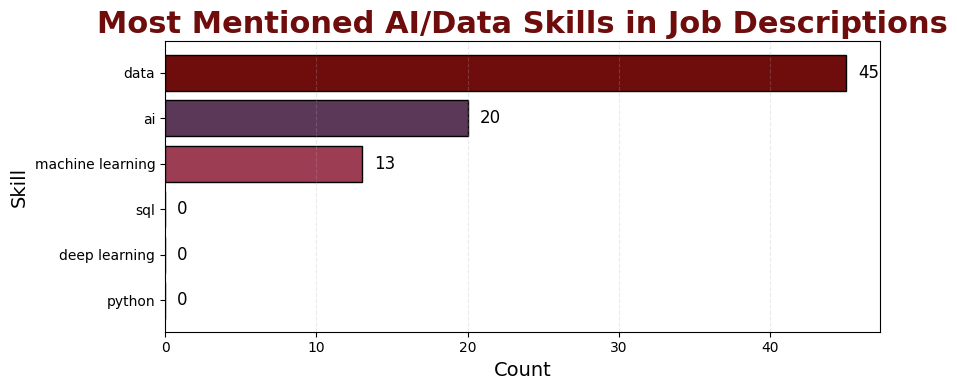

In [ ]:
# Extract and count keywords
keywords = ["python", "machine learning", "ai", "data", "deep learning", "sql"]

skill_counts = {}
for word in keywords:
    skill_counts[word] = adzuna_df['description'].str.lower().str.contains(word).sum()

skills_df = pd.DataFrame.from_dict(skill_counts, orient='index', columns=['count'])
skills_df = skills_df.sort_values('count')

# Custom aesthetic gradient
colors = ["#F4A261", "#E76F51", "#D1495B", "#9C3D54", "#5B3758"]
colors = colors[-len(skills_df):]

highlight_color = "#6E0D0C"  # burgundy

# Highlight top skill
top_skill = skills_df['count'].idxmax()

bar_colors = [
    highlight_color if skill == top_skill else colors[i]
    for i, skill in enumerate(skills_df.index)
]

# Plot
plt.figure(figsize=(9, 4))
bars = plt.barh(
    skills_df.index,
    skills_df['count'],
    color=bar_colors,
    edgecolor="black",
    linewidth=1
)

# Add count labels
for bar in bars:
    value = bar.get_width()
    plt.text(value + 0.8, bar.get_y() + bar.get_height()/2,
             f"{int(value)}", va='center', fontsize=12)

plt.title(
    "Most Mentioned AI/Data Skills in Job Descriptions",
    fontsize=22, fontweight="bold", color="#6E0D0C"
)

plt.xlabel("Count", fontsize=14)
plt.ylabel("Skill", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.25)
plt.tight_layout()
plt.show()

### Question 3: What are the top 10 most popular developer skills on StackOverflow?

#### Answer

In [ ]:
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.io import output_notebook
output_notebook()

# Prepare data
top10 = stackoverflow_df.sort_values("question_count", ascending=False).head(10)

colors = [
    "#D72638", "#F49D37", "#1B998B", "#2E294E", "#9C27B0",
    "#E91E63", "#2196F3", "#4CAF50", "#FF6F61", "#6A4C93"
]

top10["color"] = colors[:len(top10)]
top10["has_synonyms_str"] = top10["has_synonyms"].apply(lambda x: "Yes" if x else "No")

source = ColumnDataSource(top10)

p = figure(
    x_range=list(top10["tag_name"]),
    width=900,
    height=450,
    title="Top 10 Most Popular Developer Tags on StackOverflow",
    toolbar_location="right",
    tools="pan,wheel_zoom,box_zoom,reset"
)

p.vbar(
    x="tag_name",
    top="question_count",
    width=0.6,
    fill_color="color",
    line_color="white",
    line_width=1.5,
    source=source
)

p.add_tools(HoverTool(tooltips=[
    ("Tag", "@tag_name"),
    ("Questions", "@question_count{0,0}"),
    ("Has Synonyms?", "@has_synonyms_str")
]))

# Styling
p.xaxis.major_label_orientation = 1.0
p.yaxis.axis_label = "Number of Questions"
p.xaxis.axis_label = "Tag Name"
p.title.text_font_size = "19pt"
p.title.text_color = "#4A0E0E"  # deep burgundy
p.grid.grid_line_alpha = 0.2
p.background_fill_color = "#FCFCFF"

show(p)

### Question 4: What is the salary distribution for AI/Data roles?

#### Answer

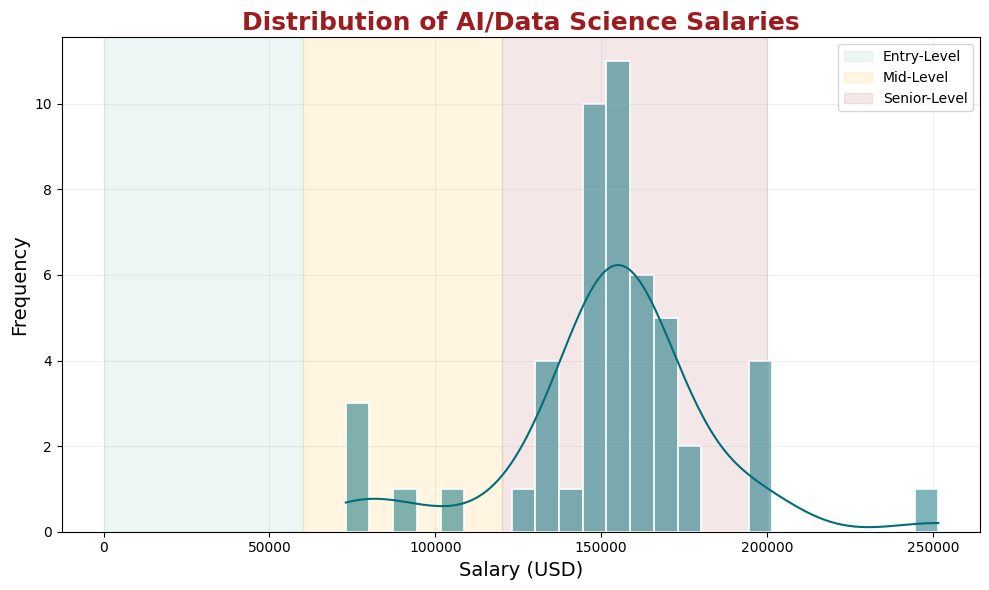

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate average salary for each posting (re-added to ensure it's always present)
adzuna_df['salary_avg'] = (adzuna_df['salary_min'] + adzuna_df['salary_max']) / 2

rich_ruby = "#9B1D20"
amber_gold = "#FFB100"
deep_teal = "#006D77"
soft_mint = "#83C5BE"
royal_purple = "#6A4C93"
sand_beige = "#F4E9CD"

plt.figure(figsize=(10,6))

# Shaded salary ranges
plt.axvspan(0, 60000, color=soft_mint, alpha=0.15, label="Entry-Level")
plt.axvspan(60000, 120000, color=amber_gold, alpha=0.12, label="Mid-Level")
plt.axvspan(120000, 200000, color=rich_ruby, alpha=0.10, label="Senior-Level")

# Histogram
sns.histplot(
    adzuna_df["salary_avg"].dropna(), # Now 'salary_avg' will be guaranteed to exist
    bins=25,
    kde=True,
    color=deep_teal,
    edgecolor="white",
    linewidth=1.2
)

plt.title("Distribution of AI/Data Science Salaries", fontsize=18, color=rich_ruby, fontweight="bold")
plt.xlabel("Salary (USD)", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.grid(alpha=0.2)

plt.legend()
plt.tight_layout()
plt.show()

### Question 5: Which cities show the highest concentration of AI jobs?

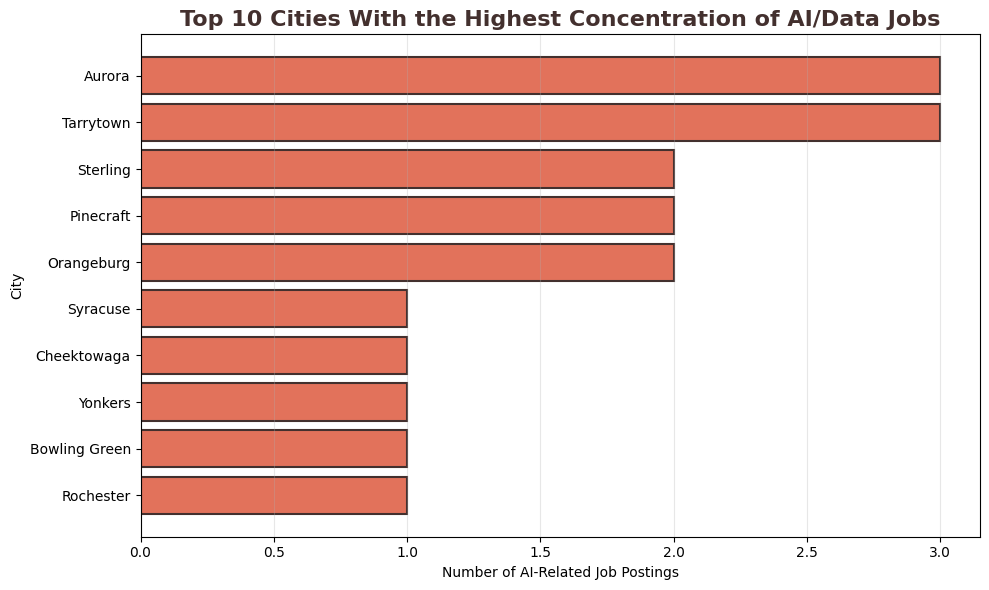

In [ ]:
import matplotlib.pyplot as plt

# Clean location data
# Some rows may have missing location — drop them
adzuna_df['location'] = adzuna_df['location'].fillna("Unknown")

# Extract city name (usually the FIRST part before comma)
adzuna_df['city'] = adzuna_df['location'].astype(str).apply(lambda x: x.split(",")[0])

# Count jobs per city
city_counts = adzuna_df['city'].value_counts().head(10)   # Top 10 cities

plt.figure(figsize=(10,6))

plt.barh(
    city_counts.index[::-1],
    city_counts.values[::-1],
    color=terracotta,
    edgecolor=old_burgundy,
    linewidth=1.5
)

plt.title("Top 10 Cities With the Highest Concentration of AI/Data Jobs",
          fontsize=16, fontweight='bold', color=old_burgundy)

plt.xlabel("Number of AI-Related Job Postings")
plt.ylabel("City")

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

##D4. Summary of key findings

* AI/Data job demand shows month-to-month fluctuation, not a smooth linear trend.
* The 3-month moving average suggests a mild upward trend, showing slow acceleration.
* A clear peak month appears, indicating AI hiring is partly cyclical or event-driven.
* The most frequently mentioned skills are Python, Data, Machine Learning, SQL, showing employers prefer practical, core data skills over advanced niche AI skills.
* StackOverflow data confirms Python is highly popular among developers, matching employer demand.
* Some top developer tags (e.g., JavaScript, HTML) do not appear in AI job postings, showing a gap between general dev interest and AI hiring needs.


##D5 Further research

* Collect more time periods to detect long-term patterns or seasonality.
* Compare cities or states to find AI job hotspots.
* Analyze salary patterns across skills or job titles.
* Use simple text analysis (NLP) to categorize job titles and responsibilities.
* Compare employer skill demand with developer skill supply in more depth.
* Add additional APIs (LinkedIn,?!) to create a multi-source dataset for stronger conclusions.

Used Chatgpt and Gemini for understanding and guidance.